In [15]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, constraints, callbacks
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# --- 1. AMS計算関数の定義 ---
def calculate_ams(s, b):
    br = 10.0
    if s <= 0 or b < 0: return 0
    return np.sqrt(2 * ((s + b + br) * np.log(1 + s / (b + br)) - s))

# --- 2. カスタムレイヤー: Max-channel Activation ---
class MaxChannel(layers.Layer):
    def __init__(self, group_size=3, **kwargs):
        super(MaxChannel, self).__init__(**kwargs)
        self.group_size = group_size

    def call(self, inputs):
        shape = tf.shape(inputs)
        reshaped = tf.reshape(inputs, [shape[0], shape[1] // self.group_size, self.group_size])
        max_vals = tf.reduce_max(reshaped, axis=2, keepdims=True)
        mask = tf.cast(tf.equal(reshaped, max_vals), inputs.dtype)
        return tf.reshape(reshaped * mask, shape)

# --- 3. 物理学的な特徴量エンジニアリング (修正版) ---
def add_physics_features(df):
    df = df.copy()
    # 正しいカラム名 (PRI_lep_pt) を使用し、存在確認を入れます
    try:
        # 質量比 (MMCは欠損値-999が多いので注意が必要だがDNNが学習に利用)
        if 'DER_mass_vis' in df.columns and 'DER_mass_MMC' in df.columns:
            df['NEW_mass_ratio'] = df['DER_mass_vis'] / (df['DER_mass_MMC'] + 1e-6)
        
        # 運動量の合計 (PRI_lep_pt に修正)
        if all(c in df.columns for c in ['DER_pt_h', 'PRI_lep_pt', 'DER_pt_tot']):
            df['NEW_total_pt'] = df['DER_pt_h'] + df['PRI_lep_pt'] + df['DER_pt_tot']
            
        # 運動量に対する質量の比
        if 'DER_pt_h' in df.columns and 'DER_mass_MMC' in df.columns:
            df['NEW_pt_mass_ratio'] = df['DER_pt_h'] / (df['DER_mass_MMC'] + 1e-6)
            
        # ジェットの個数に応じたエネルギーバランス
        if 'DER_sum_pt' in df.columns and 'PRI_jet_num' in df.columns:
            df['NEW_jet_energy_sum'] = df['DER_sum_pt'] * df['PRI_jet_num']
    except Exception as e:
        print(f"Feature engineering warning: {e}")
    return df

# --- 4. 前処理 ---
def preprocess_improved(df, is_train=True, imputer=None, scaler=None):
    df = add_physics_features(df)
    # phi を含む特徴量の削除
    df = df.drop(columns=[col for col in df.columns if "_phi" in col])
    
    drop_cols = ["EventId", "Weight", "Label"]
    X_raw = df.drop(columns=[c for c in drop_cols if c in df.columns]).values
    X_raw = np.where(X_raw == -999.0, np.nan, X_raw)
    
    if is_train:
        imputer = SimpleImputer(strategy="median")
        X = imputer.fit_transform(X_raw)
        X = np.log1p(np.maximum(X, 0))
        scaler = StandardScaler()
        X = scaler.fit_transform(X)
        return X, imputer, scaler
    else:
        X = imputer.transform(X_raw)
        X = np.log1p(np.maximum(X, 0))
        return scaler.transform(X)

# --- 5. モデル構築関数 ---
def build_stable_model(input_dim):
    class SparseConstraint(constraints.Constraint):
        def __init__(self, mask): self.mask = mask
        def __call__(self, w): return w * self.mask

    mask_np = np.zeros((input_dim, 600), dtype="float32")
    for i in range(600):
        indices = np.random.choice(input_dim, 10, replace=True)
        mask_np[indices, i] = 1.0
    sparse_mask = tf.constant(mask_np)

    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(600, 
                     kernel_regularizer=keras.regularizers.l1_l2(l1=5e-6, l2=5e-5),
                     kernel_constraint=SparseConstraint(sparse_mask)),
        MaxChannel(group_size=3),
        layers.Dropout(0.5),
        layers.Dense(600),
        MaxChannel(group_size=3),
        layers.Dropout(0.5),
        layers.Dense(2, activation="softmax")
    ])
    model.compile(optimizer=keras.optimizers.Adam(0.0005, clipnorm=1.0), 
                  loss="sparse_categorical_crossentropy")
    return model

# --- 6. 学習プロセスの実行 ---
df_train = pd.read_csv("training.csv")
X, imputer, scaler = preprocess_improved(df_train, is_train=True)
y = (df_train["Label"] == "s").astype(int).values
weights = df_train["Weight"].values

n_iterations = 3 
all_models = []
best_thresholds = []
ams_history = []

for i in range(n_iterations):
    skf = StratifiedKFold(n_splits=2, shuffle=True, random_state=i*42)
    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
        m = build_stable_model(X.shape[1])
        
        # EarlyStoppingで過学習を防ぎつつ最高の精度を狙う
        es = callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
        
        m.fit(X[train_idx], y[train_idx], 
              validation_data=(X[val_idx], y[val_idx]),
              epochs=100, batch_size=512, callbacks=[es], verbose=0)
        
        all_models.append(m)
        
        # しきい値の自動最適化
        val_probs = m.predict(X[val_idx], batch_size=4096)[:, 1]
        best_fold_ams = 0
        best_fold_th = 0
        scale_factor = len(y) / len(val_idx)
        
        for pct in np.linspace(13, 17, 41):
            th = np.percentile(val_probs, 100 - pct)
            pred = (val_probs >= th).astype(int)
            s = np.sum(weights[val_idx][(pred==1)&(y[val_idx]==1)]) * scale_factor
            b = np.sum(weights[val_idx][(pred==1)&(y[val_idx]==0)]) * scale_factor
            ams = calculate_ams(s, b)
            if ams > best_fold_ams:
                best_fold_ams = ams
                best_fold_th = th
        
        best_thresholds.append(best_fold_th)
        ams_history.append(best_fold_ams)
        print(f"Iter {i+1} Fold {fold+1}: Best AMS = {best_fold_ams:.4f} at Threshold = {best_fold_th:.4f}")

print(f"\n--- Final Results ---")
print(f"Average Optimized AMS: {np.mean(ams_history):.4f}")
print(f"Recommended Threshold: {np.mean(best_thresholds):.4f}")

31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step
Iter 1 Fold 1: Best AMS = 3.5102 at Threshold = 0.8482
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step
Iter 1 Fold 2: Best AMS = 3.4316 at Threshold = 0.8614
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step
Iter 2 Fold 1: Best AMS = 3.5232 at Threshold = 0.8206
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step
Iter 2 Fold 2: Best AMS = 3.5426 at Threshold = 0.8017
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step
Iter 3 Fold 1: Best AMS = 3.4758 at Threshold = 0.8611
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step
Iter 3 Fold 2: Best AMS = 3.5463 at Threshold = 0.8381

--- Final Results ---
Average Optimized AMS: 3.5049
Recommended Threshold: 0.8385


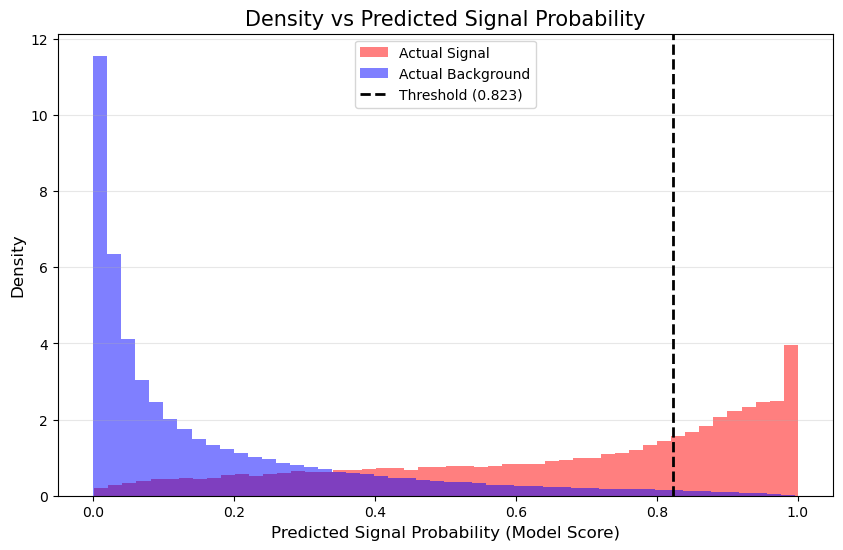

In [14]:
import matplotlib.pyplot as plt

# 1. 検証データまたはトレーニングデータでの予測スコアを取得
# ※すでに変数 signal_scores, y, weights が存在することを前提としています
# 存在しない場合は、前回のアンサンブル予測コードを実行してから使用してください

# 2. スコアを正解ラベル（Signal=1, Background=0）で分ける
scores_sig = signal_scores[y == 1]
scores_bg = signal_scores[y == 0]

# 3. 図の作成
plt.figure(figsize=(10, 6))

# 密度（Density=True）でヒストグラムを描画
# 赤が実際の信号、青が実際の背景
plt.hist(scores_sig, bins=50, density=True, alpha=0.5, color='red', 
         label='Actual Signal', histtype='stepfilled')
plt.hist(scores_bg, bins=50, density=True, alpha=0.5, color='blue', 
         label='Actual Background', histtype='stepfilled')

# 4. 最適なしきい値（Threshold）のラインを描画
# ※best_thresholds の平均などを使用
if 'best_thresholds' in locals():
    final_th = np.mean(best_thresholds)
    plt.axvline(final_th, color='black', linestyle='--', linewidth=2, 
                label=f'Threshold ({final_th:.3f})')

# 5. グラフの装飾
plt.title('Density vs Predicted Signal Probability', fontsize=15)
plt.xlabel('Predicted Signal Probability (Model Score)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend(loc='upper center')
plt.grid(axis='y', alpha=0.3)

plt.show()